In [1]:
import pandas as pd

In [3]:
data=pd.read_csv("C:\\Users\\admin\\Downloads\\done_dataset_significant_features.csv")

In [5]:
data.head()

,Age,Composition,Margin,Calcification,Echo Strength,Shape,Multifocality,FT3,Size,Blood Flow,Multilateral,Result
0,46,1,0,0,4,0,0,4,5,0,1,1
1,61,2,1,1,4,0,0,5,4,1,1,1
2,44,2,1,0,4,0,0,4,1,0,1,0
3,29,2,1,1,4,1,1,4,1,0,1,1
4,37,2,1,1,4,0,0,4,1,0,1,1


In [7]:
data.isna().sum()

Age              0
Composition      0
Margin           0
Calcification    0
Echo Strength    0
Shape            0
Multifocality    0
FT3              0
Size             0
Blood Flow       0
Multilateral     0
Result           0
dtype: int64

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [10]:
y=data['Result']
x=data.drop(columns=['Result'])

In [11]:
x.head()

,Age,Composition,Margin,Calcification,Echo Strength,Shape,Multifocality,FT3,Size,Blood Flow,Multilateral
0,46,1,0,0,4,0,0,4,5,0,1
1,61,2,1,1,4,0,0,5,4,1,1
2,44,2,1,0,4,0,0,4,1,0,1
3,29,2,1,1,4,1,1,4,1,0,1
4,37,2,1,1,4,0,0,4,1,0,1


In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

scaler=StandardScaler()

x_trained=scaler.fit_transform(x_train)

x_tested=scaler.transform(x_test)

In [13]:
param={
    'n_estimators':[100,200,300,400,500],
    'max_depth':[None,10,20,30,40],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'max_features': [ 'sqrt', 'log2'],
    'bootstrap': [True, False]
}

In [31]:
forest=RandomForestClassifier()
random_search = RandomizedSearchCV(
    estimator=forest,
    param_distributions=param,
    n_iter=50,  
    cv=5,    
    verbose=1,
   n_jobs=-1   
)
random_search.fit(x_trained,y_train)
best_model = random_search.best_estimator_
y_pred = best_model.predict(x_tested)
accuracy_score(y_test,y_pred)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


0.8578088578088578

In [32]:
forest2=RandomForestClassifier(n_estimators=250)
forest2.fit(x_trained,y_train)
y_diff=forest2.predict(x_tested)
accuracy_score(y_test,y_diff)

0.8368298368298368

In [23]:
import seaborn as sns
from sklearn.metrics import confusion_matrix,classification_report

              precision    recall  f1-score   support

           0       0.78      0.60      0.68       110
           1       0.87      0.94      0.90       319

    accuracy                           0.85       429
   macro avg       0.82      0.77      0.79       429
weighted avg       0.85      0.85      0.85       429



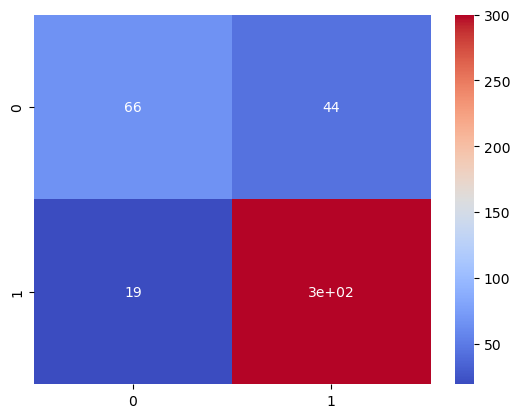

In [25]:
cm_rf=confusion_matrix(y_test,y_pred)
sns.heatmap(cm_rf,annot=True,cmap='coolwarm')
print(classification_report(y_test,y_pred))

In [19]:
logistic=LogisticRegression(max_iter=1000000)
logistic.fit(x_trained,y_train)
y_pred2=logistic.predict(x_tested)
accuracy_score(y_test,y_pred2)

0.8298368298368298

              precision    recall  f1-score   support

           0       0.62      0.41      0.50        87
           1       0.86      0.94      0.90       342

    accuracy                           0.83       429
   macro avg       0.74      0.67      0.70       429
weighted avg       0.81      0.83      0.82       429



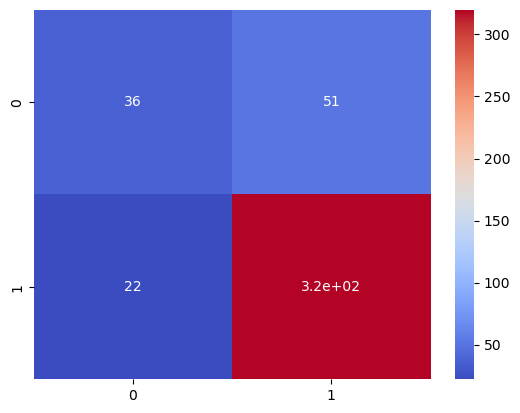

In [27]:
cm_lg=confusion_matrix(y_test,y_pred2)
sns.heatmap(cm_lg,annot=True,cmap='coolwarm')
print(classification_report(y_test,y_pred2))

In [29]:
knn=KNeighborsClassifier(n_neighbors=40)
knn.fit(x_trained,y_train)
y_pred3=knn.predict(x_tested)
accuracy_score(y_test,y_pred3)

0.8554778554778555

In [33]:
import numpy as np
param = {
    'n_neighbors': [3, 5, 7, 9,10,15,20,25,30,35,40],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

In [34]:
random_search_knn=RandomizedSearchCV(estimator=KNeighborsClassifier(),param_distributions=param,n_iter=50,verbose=1)
random_search_knn.fit(x_trained,y_train)

C:\Users\admin\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 44 is smaller than n_iter=50. Running 44 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 44 candidates, totalling 220 fits


RandomizedSearchCV(estimator=KNeighborsClassifier(), n_iter=50,
                   param_distributions={'n_neighbors': [3, 5, 7, 9, 10, 15, 20,
                                                        25, 30, 35, 40],
                                        'p': [1, 2],
                                        'weights': ['uniform', 'distance']},
                   verbose=1)

In [35]:
best_knn=random_search_knn.best_estimator_
y_knn=best_knn.predict(x_tested)
accuracy_score(y_test,y_knn)

0.8298368298368298

              precision    recall  f1-score   support

           0       0.68      0.55      0.61        87
           1       0.89      0.93      0.91       342

    accuracy                           0.86       429
   macro avg       0.78      0.74      0.76       429
weighted avg       0.85      0.86      0.85       429



<Axes: >

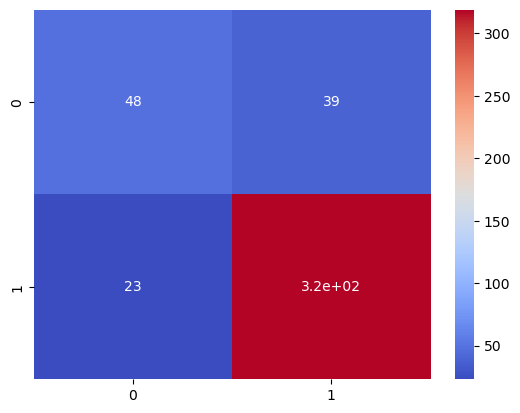

In [78]:
cm_knn=confusion_matrix(y_test,y_pred3)
print(classification_report(y_test,y_pred3))
sns.heatmap(cm_knn,annot=True,cmap='coolwarm')

In [38]:
import tensorflow

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2  

In [40]:
early_stopping=EarlyStopping(patience=5,monitor='val_accuracy',restore_best_weights=True)

In [41]:
model=Sequential()
model.add(Dense(512,input_dim=x.shape[1],activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))

C:\Users\admin\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [43]:
model.fit(x_trained,y_train,batch_size=16,epochs=30,validation_split=0.2,callbacks=[early_stopping])

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7287 - loss: 0.5403 - val_accuracy: 0.7668 - val_loss: 0.4729
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8039 - loss: 0.4376 - val_accuracy: 0.7697 - val_loss: 0.4584
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8195 - loss: 0.4411 - val_accuracy: 0.7843 - val_loss: 0.4552
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8013 - loss: 0.4630 - val_accuracy: 0.7843 - val_loss: 0.4481
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8110 - loss: 0.4096 - val_accuracy: 0.7843 - val_loss: 0.4608
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8257 - loss: 0.3865 - val_accuracy: 0.7843 - val_loss: 0.4325
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8466 - loss: 0.3899 - val_accuracy: 0.7930 - val_loss: 0.4295
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8083 - loss: 0.4028 - val_accuracy: 0.7872 - v

In [44]:
y_pred4=(model.predict(x_tested)>0.5).astype(int)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [45]:
test_loss, test_acc = model.evaluate(x_tested, y_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8322 - loss: 0.3669


In [46]:
accuracy_score(y_test,y_pred4)

0.8554778554778555

              precision    recall  f1-score   support

           0       0.63      0.69      0.66        87
           1       0.92      0.90      0.91       342

    accuracy                           0.86       429
   macro avg       0.78      0.79      0.78       429
weighted avg       0.86      0.86      0.86       429



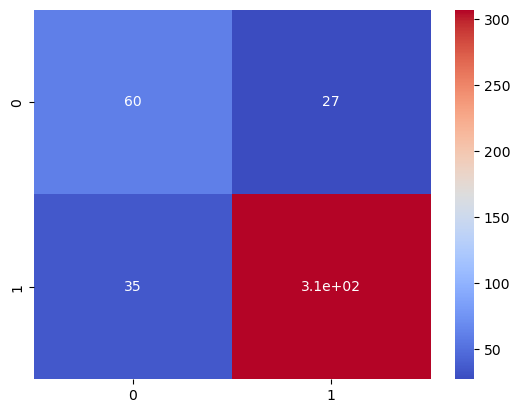

In [74]:
sns.heatmap(confusion_matrix(y_test,y_pred4),annot=True,cmap="coolwarm")
print(classification_report(y_test,y_pred4))

In [47]:
from sklearn.svm import SVC

In [48]:
svm=SVC(kernel='rbf',C=3.0,gamma='scale')

In [49]:
svm.fit(x_trained,y_train)
y_pred6=svm.predict(x_tested)
accuracy_score(y_test,y_pred6)

0.8298368298368298

In [80]:
print(classification_report(y_test,y_pred6))

              precision    recall  f1-score   support

           0       0.59      0.55      0.57        87
           1       0.89      0.90      0.89       342

    accuracy                           0.83       429
   macro avg       0.74      0.73      0.73       429
weighted avg       0.83      0.83      0.83       429



In [50]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
import numpy as np

# Define the parameter grid
param_grid = {
    'C': np.logspace(-3, 2, 6),          # Regularization parameter
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'gamma': ['scale', 'auto'],           # Kernel coefficient
    'degree': [2, 3, 4]                   # Only used if kernel='poly'
}
svc = SVC()

# RandomizedSearchCV
random_search_svm = RandomizedSearchCV(
    estimator=svc,
    param_distributions=param_grid,
    n_iter=20,          # Number of random combinations to try
    scoring='accuracy', # You can change scoring metric
    cv=5,               # 5-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1           # Use all cores
)

# Fit the model
random_search_svm.fit(x_trained, y_train)

print("Best parameters:", random_search_svm.best_params_)
print("Best score:", random_search_svm.best_score_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'kernel': 'rbf', 'gamma': 'auto', 'degree': 2, 'C': 1.0}
Best score: 0.8265220875317546


In [70]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Base learners
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42))
]

# Meta-learner (final estimator)
stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    passthrough=False,  # if True, meta-learner also gets original features
    cv=5
)

# Train stacking model
stack_clf.fit(x_trained, y_train)

# Predictions
y_pred = stack_clf.predict(x_tested)

print("Stacking Ensemble Accuracy:", accuracy_score(y_test, y_pred))


Stacking Ensemble Accuracy: 0.8578088578088578


              precision    recall  f1-score   support

           0       0.66      0.61      0.63        87
           1       0.90      0.92      0.91       342

    accuracy                           0.86       429
   macro avg       0.78      0.77      0.77       429
weighted avg       0.85      0.86      0.86       429



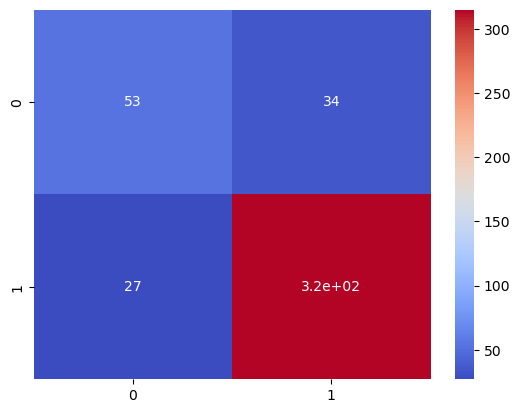

In [76]:
sns.heatmap(confusion_matrix(y_test,y_pred),cmap='coolwarm',annot=True)
print(classification_report(y_test,y_pred))